In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('dark_background')

In [54]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns', None)

In [55]:
from sklearn.datasets import fetch_openml
titenic = fetch_openml('titanic', version=1, as_frame=True)
df = titenic.frame
df.head(5)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [56]:
df.describe(include='number')

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [57]:
df.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014


#Handling Missing Values

In [58]:
# To fill missing values in 'Embarked' Column with Mode as it has categorical values.
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)
df['embarked'].isnull().sum()

np.int64(0)

In [59]:
# To Fill NaN in 'Age' column with median value
df['age'].fillna(df['age'].mean(), inplace=True)
df['age'].isnull().sum()

np.int64(0)

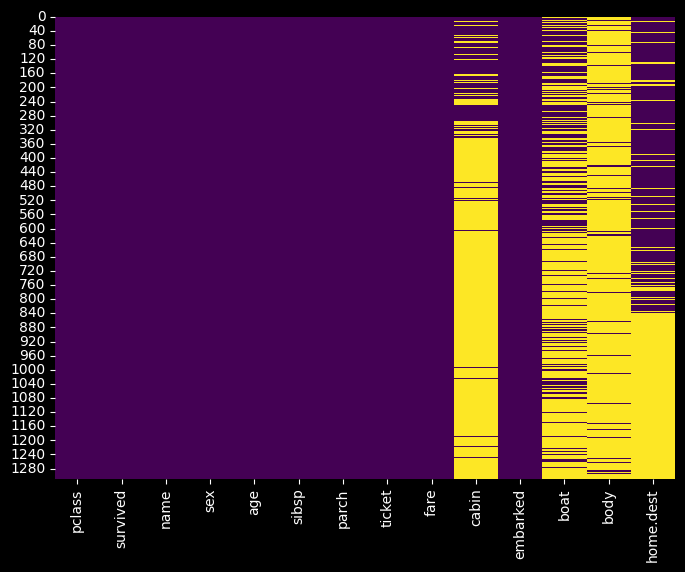

In [60]:
# To see the heatmap of null values in the dataset
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [61]:
print(f"Previous(Data Shape): {df.shape}")
df_2 = df.drop(['ticket','cabin','boat','body','home.dest'], axis=1)
df_2 = df_2.dropna(axis=0)
print(f"Clean (Data Shape): {df_2.shape}\n")
print(f"Null value in data: \n {df_2.isnull().sum()}")

Previous(Data Shape): (1309, 14)
Clean (Data Shape): (1308, 9)

Null value in data: 
 pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


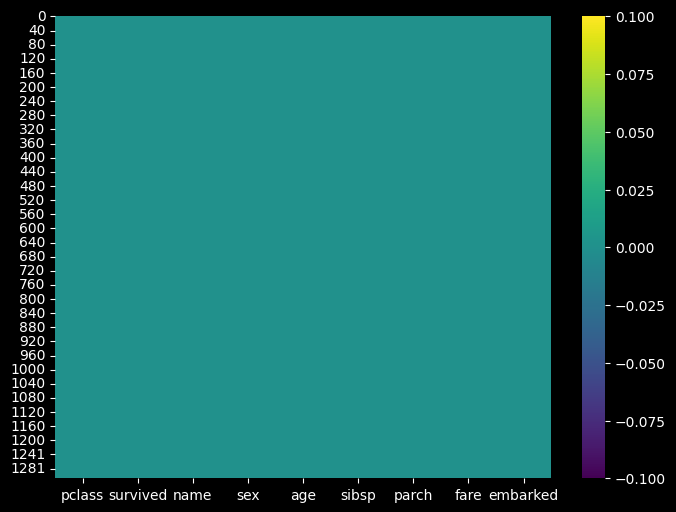

In [62]:
# To See the Heatmap of clean data regarding null values
plt.figure(figsize=(8,6))
sns.heatmap(df_2.isnull(), cbar= True, cmap= 'viridis')
plt.show()

#Feature Engineering

In [63]:
# 1. Naam me se Title (Mr, Mrs, Miss) nikalna
df_2['Title'] = df_2['name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# # 2. Rare titles ko common names me convert karna (jaise Mile, Ms -> Miss)
df_2['Title'] = df_2['Title'].replace(['Mlle', 'Ms'], 'Miss')
df_2['Title'] = df_2['Title'].replace('Mme', 'Mrs')
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df_2['Title'] = df_2['Title'].replace(rare_titles, 'Rare')

# To claculate family_size by (passenger + Sibsp + Parch)

df_2['family_size'] = df_2['sibsp']+ df_2['parch']+1
df_2['is_alone'] = (df_2['family_size']==1).astype(int)

df_3 = df_2.drop(['name','sibsp','parch'], axis=1)
print(f"Data 2 Shape: {df_2.shape}")
print(f"Data 3 Shape: {df_3.shape}")
print(df_3.head())

Data 2 Shape: (1308, 12)
Data 3 Shape: (1308, 9)
   pclass survived     sex      age      fare embarked   Title  family_size  \
0       1        1  female  29.0000  211.3375        S    Miss            1   
1       1        1    male   0.9167  151.5500        S  Master            4   
2       1        0  female   2.0000  151.5500        S    Miss            4   
3       1        0    male  30.0000  151.5500        S      Mr            4   
4       1        0  female  25.0000  151.5500        S     Mrs            4   

   is_alone  
0         1  
1         0  
2         0  
3         0  
4         0  


# Data Distribution

In [64]:
numeric_cols = df_3.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df_3.select_dtypes(include=['object','category']).columns.tolist()
print(f"Numeric Columns: {numeric_cols}")
print(f"Categorical Columns: {cat_cols}")

Numeric Columns: ['pclass', 'age', 'fare', 'family_size', 'is_alone']
Categorical Columns: ['survived', 'sex', 'embarked', 'Title']


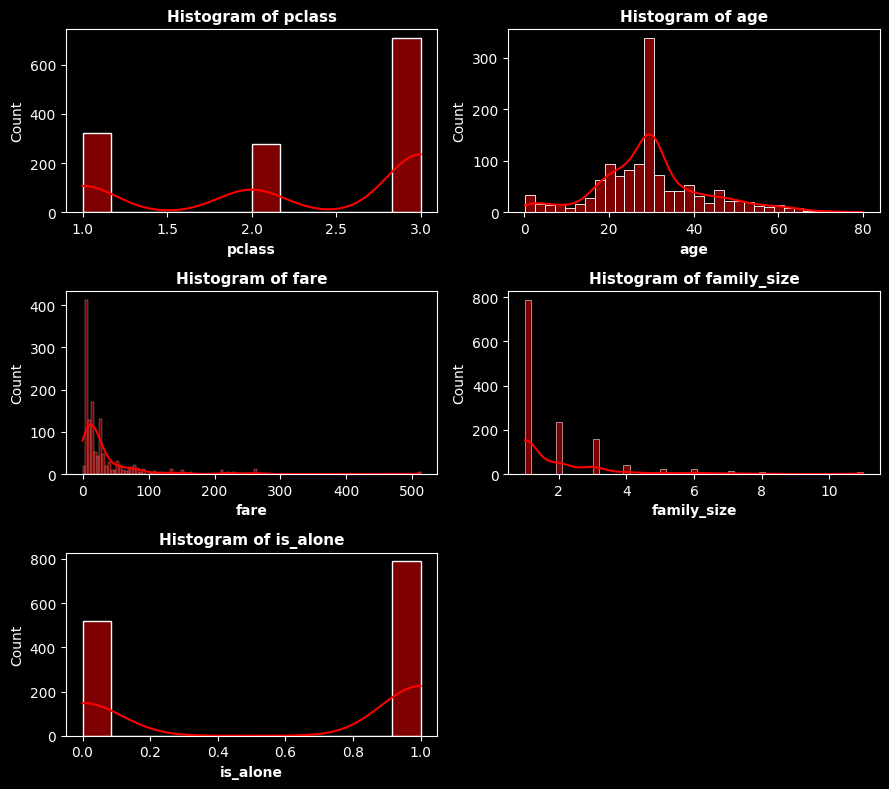

In [65]:
# Data distribution of numeric_cols through Histplot
import math
num_cols = len(numeric_cols)
grid_cols = 2
grid_rows = math.ceil(num_cols/grid_cols)

plt.figure(figsize= (grid_rows*3, grid_cols*4))
for index, i in enumerate(numeric_cols):
  plt.subplot(grid_rows, grid_cols, index+1)
  sns.histplot(x=i, data=df_3, color='red', kde=True)
  plt.xlabel(i, fontsize=10, fontweight='bold')
  plt.title(f"Histogram of {i}", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

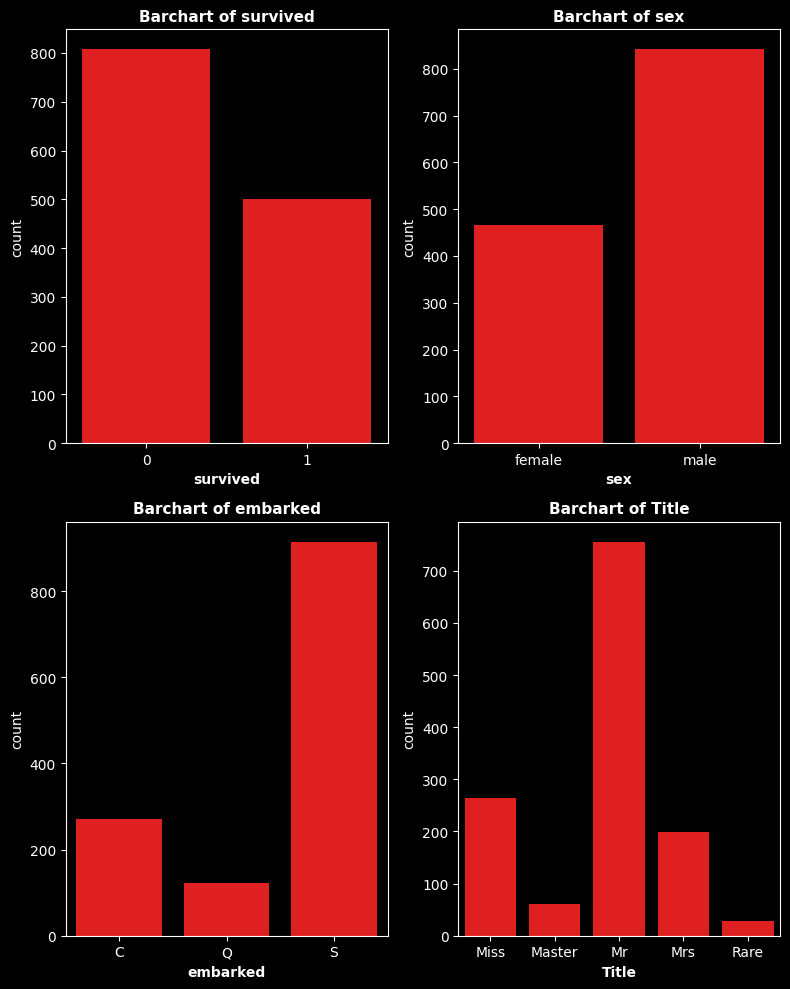

In [66]:
# Data Distribution of cat_cols through barchart
import math
num_cols = len(cat_cols)
grid_cols = 2
grid_rows  =math.ceil(len(cat_cols)/grid_cols)

plt.figure(figsize= (grid_rows*4, grid_cols*5))
for index, i in enumerate(cat_cols):
  plt.subplot(grid_rows, grid_cols, index+1)
  sns.countplot(x=i, data=df_3, color='red')
  plt.xlabel(i, fontsize=10, fontweight='bold')
  plt.title(f"Barchart of {i}", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

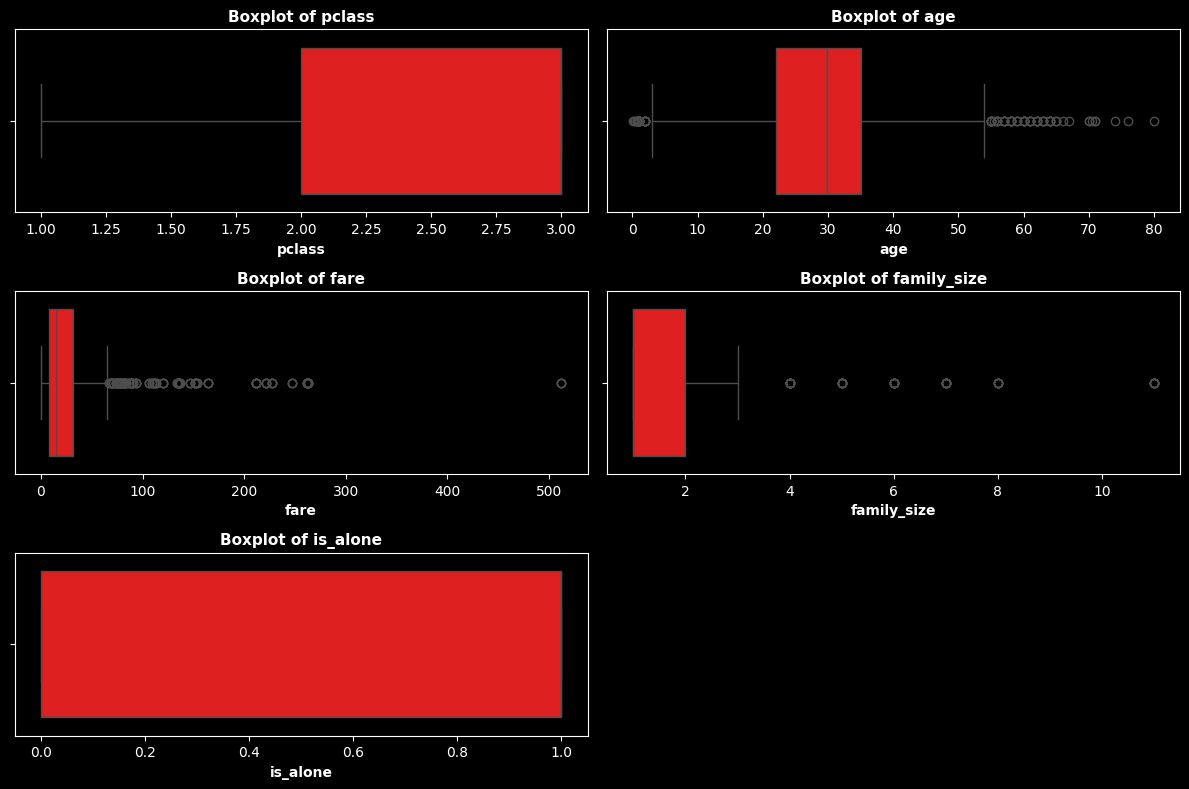

In [67]:
# See numeric_cols Outliers through Boxplot
import math
num_cols = len(numeric_cols)
grid_cols = 2
grid_rows  = math.ceil(num_cols/grid_cols)

plt.figure(figsize= (grid_rows*4, grid_cols*4))
# plt.figure(figsize= (12, 10))
for index, i in enumerate(numeric_cols):
  plt.subplot(grid_rows, grid_cols, index+1)
  sns.boxplot(x=i, data=df_3,color= 'red')
  plt.xlabel(i, fontsize=10, fontweight='bold')
  plt.title(f"Boxplot of {i}", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plot to see the relation b/w Age & Fair

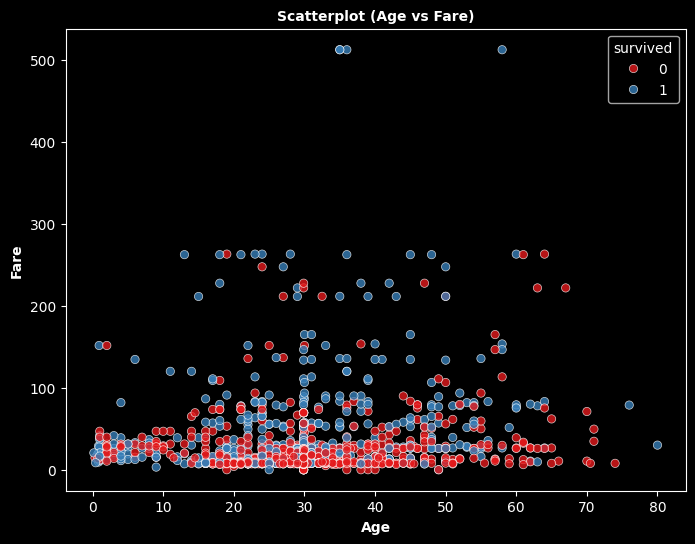

In [68]:
plt.figure(figsize=(8, 6))

# X aur Y par numerical columns honge, aur hue par aapka categorical target hoga
sns.scatterplot(x='age', y='fare', hue='survived', data=df_3, palette='Set1', alpha=0.8)
plt.title('Scatterplot (Age vs Fare)',fontsize=10, fontweight='bold')
plt.xlabel('Age',fontsize=10, fontweight='bold')
plt.ylabel('Fare',fontsize=10, fontweight='bold')
plt.show()



But we can't get the exact information for a dot in this diagram, so we draw scatter plot through plotly.

In [69]:
import plotly.express as px

# Interactive scatter plot banana
fig = px.scatter(df_2, x='age', y='fare',
    color='survived',          # Target variable ka rang
    hover_name='sex',         # Pop-up ke heading mein kya dikhe (e.g., Passenger Name)
    hover_data=['pclass', 'sex'], # Aur kaun si details pop-up mein dikhani hain
    title='Interactive Scatter Plot: Age vs Fare'
)

# Graph ko display karna
fig.show()


# One Hot Encoding

In [70]:
df_clean = pd.get_dummies(df_3, columns=['Title','sex','embarked'], drop_first=True, dtype=int)
print(df_clean.head())


   pclass survived      age      fare  family_size  is_alone  Title_Miss  \
0       1        1  29.0000  211.3375            1         1           1   
1       1        1   0.9167  151.5500            4         0           0   
2       1        0   2.0000  151.5500            4         0           1   
3       1        0  30.0000  151.5500            4         0           0   
4       1        0  25.0000  151.5500            4         0           0   

   Title_Mr  Title_Mrs  Title_Rare  sex_male  embarked_Q  embarked_S  
0         0          0           0         0           0           1  
1         0          0           0         1           0           1  
2         0          0           0         0           0           1  
3         1          0           0         1           0           1  
4         0          1           0         0           0           1  


In [71]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_clean.drop('survived', axis=1).astype(int), df_clean['survived'].astype(int), test_size=0.2, random_state=42)


In [72]:
from sklearn.preprocessing import StandardScaler
sc  = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [73]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)


LogisticRegression()

In [74]:
model.score(x_train, y_train)

0.8202676864244742

In [75]:

model.score(x_test, y_test)

0.7862595419847328

In [76]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=10)
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [77]:
model.score(x_train, y_train)

0.8221797323135756

In [78]:
model.score(x_test, y_test)

0.7824427480916031

In [79]:
# SVC
from sklearn.svm import SVC
model = SVC(C=1.0, gamma='scale', kernel='poly')
model.fit(x_train,y_train)

SVC(kernel='poly')

In [80]:
model.score(x_train, y_train)

0.8355640535372849

In [81]:
model.score(x_test,y_test)

0.7786259541984732

In [82]:
# DecisionTree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion= 'gini', max_depth=5)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [83]:
model.score(x_train, y_train)

0.8365200764818356

In [84]:
model.score(x_test, y_test)

0.7786259541984732

In [85]:
# RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, criterion='entropy',max_depth=5)
model.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5)

In [86]:
model.score(x_train,y_train)

0.8279158699808795

In [87]:
model.score(x_test, y_test)

0.7824427480916031

In [88]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2)
model.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=2)

In [89]:
model.score(x_train, y_train)

0.8374760994263862

In [90]:
model.score(x_test, y_test)

0.7900763358778626

In [91]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
model.fit(x_train, y_train)

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)

In [92]:
model.score(x_train, y_train)

0.8011472275334608

In [93]:
model.score(x_test, y_test)

0.7519083969465649

In [94]:
# XGBoost
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200,learning_rate=0.2, max_depth=2)
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [95]:
model.score(x_train, y_train)

0.861376673040153

In [96]:
model.score(x_test,y_test)

0.8206106870229007

# Applying Deep Learning

In [97]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# Model building
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),   # Input Layer & 1st Hidden Layer
    Dropout(0.2),                                                     # Droping 20% neurons of 1st layer to stop overfitting.
    Dense(64, activation='relu'),                                     # Hidden Layers
    Dense(32, activation='relu'),

    # Output Layer:
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

# model training

In [98]:
# 3. Early Stopping (Yeh 5% se zyada gap badhne hi nahi dega)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,                 # Agar 6 epochs tak validation loss nahi sudhra, training stop!
    restore_best_weights=True    # Sabse best aur balanced weights par wapas le aayega
)

In [99]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
history_df = pd.DataFrame(history.history)
print(f"\n Epoch-wise Raw Data in last 5 rows : \n {history_df.tail()}")       # Epoch-wise Raw Data in last 5 rows to see the train accuracy and validation loss at last epoch

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7153 - loss: 0.6222 - val_accuracy: 0.7524 - val_loss: 0.5495
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8038 - loss: 0.4661 - val_accuracy: 0.7667 - val_loss: 0.5245
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8194 - loss: 0.4324 - val_accuracy: 0.7762 - val_loss: 0.5001
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8278 - loss: 0.4208 - val_accuracy: 0.7714 - val_loss: 0.4909
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8266 - loss: 0.4142 - val_accuracy: 0.7810 - val_loss: 0.4757
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8361 - loss: 0.4130 - val_accuracy: 0.7857 - val_loss: 0.4899
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8313 - loss: 0.4129 - val_accuracy: 0.7810 - val_loss: 0.4712
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8421 - loss: 0.4003 - val_accuracy: 0.7857 - 

# Training vs Validation Loss plot (visualization):


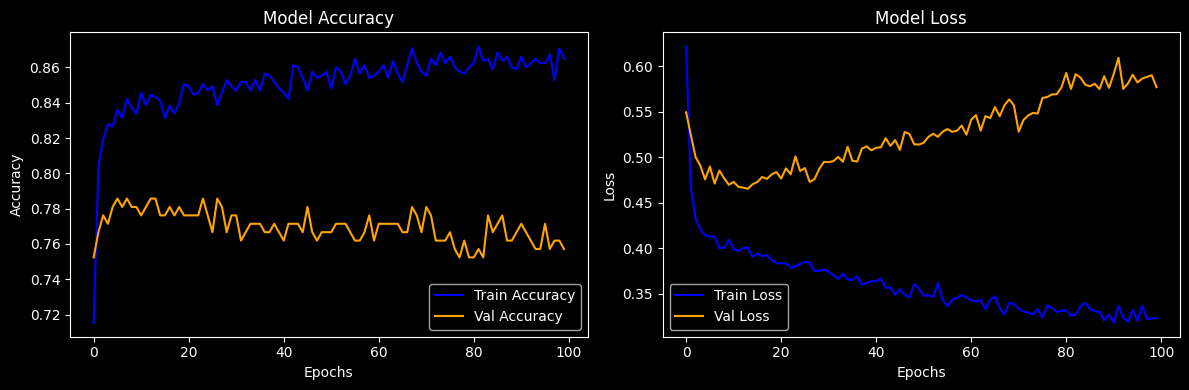

In [100]:
plt.figure(figsize=(12, 4))

# Plot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


As We see that Deep Learning concept is not giving so good result beacuse it's a small Data set.

# Selecting Best model through PipeLine

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Imported models :--
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base Pipeline :--

base_pipeline = Pipeline([('scaler', StandardScaler()),
                          ('model', SVC())])

In [102]:
# Dict of Models
best_score = 0
best_model = None
best_model_name = ""

model_param = {
    'logist_reg':{
        'model' : [LogisticRegression()],
        'model__C' : [0.1, 1, 10]
                },

    'k_neighbors' : {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors' : [3, 5, 10]
                },
    'svc' : {
        'model' : [SVC()],
        'model__C' : [0.1, 1, 10],
        'model__gamma' : [0.1, 0.01, 'scale'],
        'model__kernel' : ['sigmoid', 'poly', 'rbf']
                },
    'dtc' : {
        'model' : [DecisionTreeClassifier()],
        'model__max_depth' : [None, 5, 10],
        'model__criterion' : ['gini', 'entropy']
                },
    'random_forest' : {
        'model' : [RandomForestClassifier()],
        'model__n_estimators' : [100, 200],
        'model__max_depth' : [None, 5],
        'model__criterion' : ['gini', 'entropy']
                },
    'gradient_boost' : {
        'model' : [GradientBoostingClassifier()],
        'model__n_estimators' : [100, 150, 200],
        'model__learning_rate' : [0.01, 0.1, 0.2],
        'model__max_depth' : [2, 3, 4]
                },
    'adaboost' : {
        'model' : [AdaBoostClassifier()],
        'model__n_estimators' : [50, 100],
        'model__learning_rate' : [0.01, 0.1]
                },
    'xgboost' : {
        'model' : [XGBClassifier()],
        'model__n_estimators' : [100, 200],
        'model__learning_rate' : [0.01, 0.1, 0.2],
        'model__max_depth' : [2, 3, 4]
                }
        }
for model_name, param_grid in model_param.items():
    clf = GridSearchCV(base_pipeline, param_grid=param_grid, cv=5, n_jobs=-1)
    clf.fit(x_train, y_train)
    print(f"\n{model_name.upper()}")
    print(f"Best CV Score: {clf.best_score_:.4f}")

    clean_params = {k.split('__')[1]: v for k, v in clf.best_params_.items() if '__' in k}

    current_y_pred = clf.predict(x_test)                          # 1. Current model ki prediction & test accuracy nikalna (for Loop ke liye)
    acc = accuracy_score(y_test, current_y_pred)
    print(f"{model_name} Test Accuracy: {acc:.4f}")
    print(f"Best Params: {clean_params}")

    # Overall Best Model ko track karne ke liye logic
    if clf.best_score_ > best_score:
      best_score = clf.best_score_
      best_model = clf.best_estimator_
      best_model_name = model_name
      best_params_dict = clean_params
      y_pred = best_model.predict(x_test) # Winner model ki prediction

print("\n OVERALL CHAMPION MODEL SUMMARY:")
print(f"Winner Model Key : {best_model_name}")
print(f"Max CV Accuracy  : {best_score:.4f}")
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print(f"Classification Report for {best_model.named_steps['model'].__class__.__name__}:\n {classification_report(y_test, y_pred)}")
print(f"Confusion Matrix for {best_model.named_steps['model'].__class__.__name__}: \n{confusion_matrix(y_test, y_pred)}")



LOGIST_REG
Best CV Score: 0.8126
logist_reg Test Accuracy: 0.7863
Best Params: {'C': 1}

K_NEIGHBORS
Best CV Score: 0.8002
k_neighbors Test Accuracy: 0.7824
Best Params: {'n_neighbors': 10}

SVC
Best CV Score: 0.8231
svc Test Accuracy: 0.7824
Best Params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

DTC
Best CV Score: 0.7944
dtc Test Accuracy: 0.7824
Best Params: {'criterion': 'entropy', 'max_depth': 5}

RANDOM_FOREST
Best CV Score: 0.8202
random_forest Test Accuracy: 0.7786
Best Params: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}

GRADIENT_BOOST
Best CV Score: 0.8183
gradient_boost Test Accuracy: 0.7824
Best Params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 150}

ADABOOST
Best CV Score: 0.7992
adaboost Test Accuracy: 0.7519
Best Params: {'learning_rate': 0.1, 'n_estimators': 100}

XGBOOST
Best CV Score: 0.8174
xgboost Test Accuracy: 0.8092
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}

 OVERALL CHAMPION MODEL SUMMARY:
Winner Model K

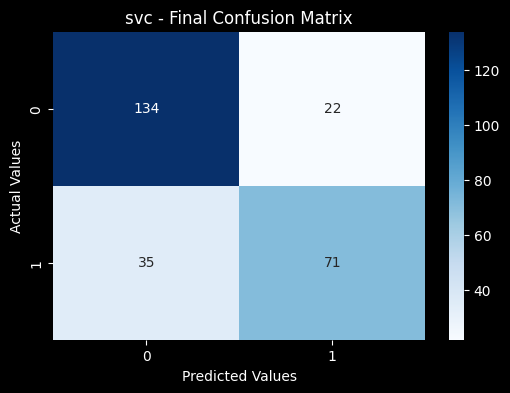

In [103]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title(f"{best_model_name} - Final Confusion Matrix")
plt.show()


So we find **Support Vector Classifier (SVC)** as best fit model for Titanic Data set.